<a href="https://colab.research.google.com/github/Th3N1zz/Data-Analysis-Project/blob/main/Projeto_AED_An%C3%A1lise_de_Dados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **GRUPO**


---


Beatriz Búfalo 10417284

Giuliana Fukuda 10238985

Gustavo Diniz 10416784

Maria Luiza Kroll 10408581

## **Objetivo do Projeto**

---

O projeto visa analisar dados clínicos relacionados ao diabetes, dados extraídos da fonte Kaggle Datasets, para:

- Explorar padrões e correlações entre variáveis.
- Avaliar fatores que influenciam o diagnóstico (***variável Outcome***).

## **Etapa 1: Importação e Carregamento dos Dados**

---

Bibliotecas utilizadas/importadas:
- Pandas & numpy: Coleta, limpeza, preparação e descrição dos dados
- Matplotlib & Seaborn: Análise e visualização dos dados

In [ ]:
#Importar bibliotecas, ler o arquivo e mostrar as 10 primeiras linhas (head)
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
database = pd.read_csv('https://raw.githubusercontent.com/Th3N1zz/Data-Analysis-Project/refs/heads/main/diabetes_dataset.csv', sep =',')
database.head(10)

,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,...,41,160,145,136,236,6.36,8.18,29.6,Type 2,1
1,48,Female,White,Highschool,Middle,Employed,Former,1,143,6.7,...,55,50,30,93,150,2.00,5.63,23.0,No Diabetes,0
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,...,66,99,36,118,195,5.07,7.51,44.7,Type 2,1
3,74,Female,Black,Highschool,Low,Retired,Never,0,49,3.4,...,50,79,140,139,253,5.28,9.03,38.2,Type 2,1
4,46,Male,White,Graduate,Middle,Retired,Never,1,109,7.2,...,52,125,160,137,184,12.74,7.20,23.5,Type 2,1
5,46,Female,White,Highschool,Upper-Middle,Employed,Never,2,124,9.0,...,61,119,179,100,133,8.77,6.03,23.5,Pre-Diabetes,0
6,75,Female,White,Graduate,Upper-Middle,Retired,Never,0,53,9.2,...,46,161,155,101,100,10.14,5.24,36.1,Pre-Diabetes,0
7,62,Male,White,Postgraduate,Middle,Unemployed,Current,1,75,4.1,...,49,159,120,110,189,8.96,7.04,34.2,Type 2,1
8,42,Male,Black,Highschool,Lower-Middle,Employed,Current,1,114,6.7,...,33,132,98,116,172,5.70,6.90,26.7,Type 2,1
9,59,Female,White,Graduate,Middle,Employed,Current,3,86,8.2,...,52,103,104,76,109,4.49,4.99,30.0,No Diabetes,0


### Visualização inicial dos dados

In [ ]:
database.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 31 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   age                                 100000 non-null  int64  
 1   gender                              100000 non-null  object 
 2   ethnicity                           100000 non-null  object 
 3   education_level                     100000 non-null  object 
 4   income_level                        100000 non-null  object 
 5   employment_status                   100000 non-null  object 
 6   smoking_status                      100000 non-null  object 
 7   alcohol_consumption_per_week        100000 non-null  int64  
 8   physical_activity_minutes_per_week  100000 non-null  int64  
 9   diet_score                          100000 non-null  float64
 10  sleep_hours_per_day                 100000 non-null  float64
 11  screen_time_hours_per_day  

## **Etapa 2: Limpeza e preparação dos dados**

---



In [ ]:
#Remoção de colunas que não serão utilizadas para análise da base
database = database.drop(columns=['education_level','income_level','employment_status','screen_time_hours_per_day','waist_to_hip_ratio','systolic_bp','diastolic_bp','heart_rate'])

In [ ]:
database

,age,gender,ethnicity,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,family_history_diabetes,hypertension_history,...,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
0,58,Male,Asian,Never,0,215,5.7,7.9,0,0,...,41,160,145,136,236,6.36,8.18,29.6,Type 2,1
1,48,Female,White,Former,1,143,6.7,6.5,0,0,...,55,50,30,93,150,2.00,5.63,23.0,No Diabetes,0
2,60,Male,Hispanic,Never,1,57,6.4,10.0,1,0,...,66,99,36,118,195,5.07,7.51,44.7,Type 2,1
3,74,Female,Black,Never,0,49,3.4,6.6,0,0,...,50,79,140,139,253,5.28,9.03,38.2,Type 2,1
4,46,Male,White,Never,1,109,7.2,7.4,0,0,...,52,125,160,137,184,12.74,7.20,23.5,Type 2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,46,Male,Other,Former,1,136,8.3,6.4,0,0,...,45,150,116,113,109,14.58,5.55,26.0,Pre-Diabetes,0
99996,41,Female,White,Never,3,76,8.8,6.8,0,0,...,55,123,146,96,146,9.02,5.97,24.4,Pre-Diabetes,0
99997,57,Female,Black,Former,4,121,9.9,5.0,0,0,...,50,111,184,93,132,2.57,5.21,27.6,No Diabetes,0
99998,47,Female,Black,Never,3,52,5.9,6.7,0,1,...,68,91,116,106,117,9.81,5.53,26.4,Pre-Diabetes,0


## **Etapa 3: Descrição dos dados**

---

Visualização das primeiras linhas, dimensões e seus tipos, estatísticas gerais, verificação de valores nulos ou faltantes.

### Visualização da estrutura da base de dados

In [ ]:
database.shape

(100000, 23)

### Visualização das características gerais da base de dados

In [ ]:
database.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 23 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   age                                 100000 non-null  int64  
 1   gender                              100000 non-null  object 
 2   ethnicity                           100000 non-null  object 
 3   smoking_status                      100000 non-null  object 
 4   alcohol_consumption_per_week        100000 non-null  int64  
 5   physical_activity_minutes_per_week  100000 non-null  int64  
 6   diet_score                          100000 non-null  float64
 7   sleep_hours_per_day                 100000 non-null  float64
 8   family_history_diabetes             100000 non-null  int64  
 9   hypertension_history                100000 non-null  int64  
 10  cardiovascular_history              100000 non-null  int64  
 11  bmi                        

**Smoking Status**


---

Indica se a pessoa nunca fumou, é ex-fumante ou fumante atual. Utilizada para avaliar impacto do tabaco em fatores metabólicos.

**Diet Score**


---

Índice que avalia a qualidade da alimentação. Quanto maior, melhor a dieta

**Histórico familiar de diabetes**


---
Indica se a pessoa possui ou não histórico familiar da doença (variável binária 0 - 1)


**BMI**

---

Equialente ao IMC - Índice de Massa Corporal

**Colesterol Total**


---

Nível total de colesterol no sangue. Usado para avaliar risco cardiovascular

**Colesterol HDL (lipoproteína de alta densidade)**


---

Fração do colesterol protetora, sua função envole a remoção o excesso de colesterol das artérias

**Colesterol LDL (lipoproteína de baixa densidade)**


---

Fração do colesterol ligada a problemas cardiovasculares, sua função envole transportar colesterol do fígado para as células

**Triglicerídeos**


---

Lipídios (gorduras) no sangue, essenciais como reserva de energia, mas perigosos em níveis elevados

**Glucose Fasting — Glicose em jejum**


---

Nível de glicose após jejum de 8h. Principal métrica para identificar pré-diabetes e diabetes.

**Glucose Postprandial — Glicose pós-prandial**


---

Glicose medida após refeição. Revela picos glicêmicos difíceis de detectar no jejum.

**Insulin level — Nível de insulina**


---

Quantidade de insulina circulante. Ajuda a identificar resistência à insulina ou deficiência.

**hba1c — Hemoglobina glicada**


---

Média da glicose dos últimos 3 meses. Indicador clínico definitivo para diagnóstico de diabetes.

**Diabetes Risk Score — Score de risco**


---

Pontuação baseada em múltiplos fatores que estima a probabilidade de desenvolver diabetes.

**Diabetes Stage — Estágio/Tipo de diabetes**


---

Classificação do status do indivíduo: sem diabetes, pré-diabetes, diabetes gestacinal, tipo 1 e tipo 2

**Diagnosed Diabetes — Diagnóstico clínico**


---

Indica se o indivíduo recebeu diagnóstico médico confirmado de diabetes, de forma binária (0 - 1)

### Visualização das estatísticas gerais da base de dados



In [ ]:
#Visualização das estatísticas gerais da base de dados
database.describe()

,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,family_history_diabetes,hypertension_history,cardiovascular_history,bmi,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diagnosed_diabetes
count,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50.12041,2.003670,118.911640,5.994787,6.997818,0.219410,0.250800,0.079200,25.612653,185.978110,54.042790,103.000430,121.462650,111.11712,160.035050,9.061242,6.520776,30.222362,0.599980
std,15.60460,1.417779,84.409662,1.780954,1.094622,0.413849,0.433476,0.270052,3.586705,32.013005,10.267374,33.390256,43.372619,13.59561,30.935472,4.954060,0.813921,9.061505,0.489904
min,18.00000,0.000000,0.000000,0.000000,3.000000,0.000000,0.000000,0.000000,15.000000,100.000000,20.000000,50.000000,30.000000,60.00000,70.000000,2.000000,4.000000,2.700000,0.000000
25%,39.00000,1.000000,57.000000,4.800000,6.300000,0.000000,0.000000,0.000000,23.200000,164.000000,47.000000,78.000000,91.000000,102.00000,139.000000,5.090000,5.970000,23.800000,0.000000
50%,50.00000,2.000000,100.000000,6.000000,7.000000,0.000000,0.000000,0.000000,25.600000,186.000000,54.000000,102.000000,121.000000,111.00000,160.000000,8.790000,6.520000,29.000000,1.000000
75%,61.00000,3.000000,160.000000,7.200000,7.700000,0.000000,1.000000,0.000000,28.000000,208.000000,61.000000,126.000000,151.000000,120.00000,181.000000,12.450000,7.070000,35.600000,1.000000
max,90.00000,10.000000,833.000000,10.000000,10.000000,1.000000,1.000000,1.000000,39.200000,318.000000,98.000000,263.000000,344.000000,172.00000,287.000000,32.220000,9.800000,67.200000,1.000000


### **Insights obtidos com a análise gráfica:**

---
Com os valores obtidos acima, é possível identificar as indicações das seguintes médias:
- Avaliação da dieta se concentra em 6, indicando estarem na média
- Indicam que as pessoas costuam dormir 7 horas por dia, em média
- As pessoas costumam praticar 2 horas de atividade física por semana
- O IMC está em 25, indicando a maior parte das pessoas em sobrepeso

## **Etapa 4: Análise e Visualização dos dados**


---



### Frequência relativa por tipo de diabetes

In [ ]:
tp_relativa_percent = database['diabetes_stage'].value_counts(normalize=True) * 100
tp_relativa_percent

,proportion
diabetes_stage,
Type 2,59.774
Pre-Diabetes,31.845
No Diabetes,7.981
Gestational,0.278
Type 1,0.122


### **Insights obtidos com a análise gráfica:**

---
Conclui-se que maioria dos entrevistados tem DM2, e a quantidade de diabtéticos tipo 1 é menor até mesmo do que a quantidade de não diabéticos

###**Pefil Demográfico dos entrevistados**


---



### Distribuição por Etnia

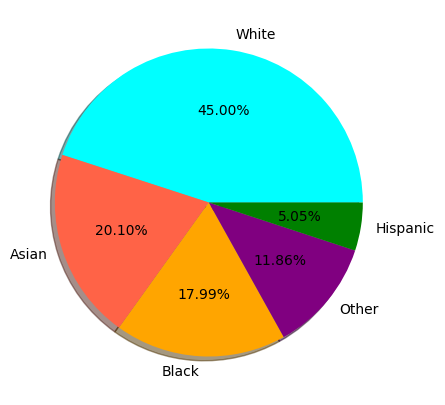

In [ ]:
plt.figure(figsize=(10,5))
plt.pie(database.ethnicity.value_counts(), labels= ['White','Asian','Black','Other','Hispanic'], autopct='%1.2f%%', colors=['cyan','tomato', 'orange','Purple', 'green'], shadow=True)
plt.show()

### Distribuição de Gênero

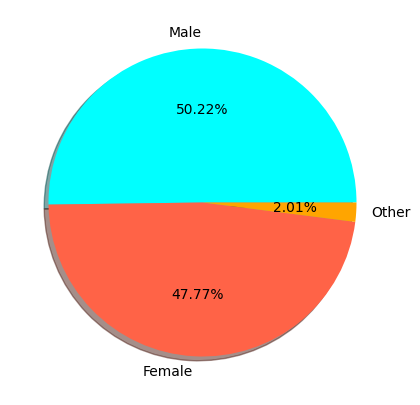

In [ ]:
plt.figure(figsize=(10,5))
plt.pie(database.gender.value_counts(), labels= database.gender.unique(), autopct='%1.2f%%', colors=['cyan','tomato', 'orange'], shadow=True)
plt.show()

### Frequência de idade por categoria


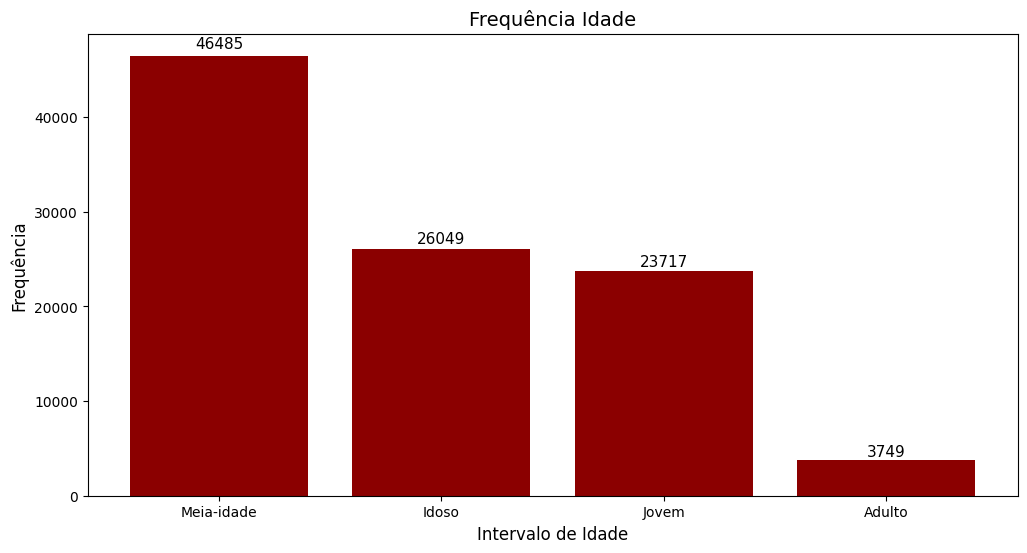

In [ ]:
database['Idade'] = pd.cut(database['age'], bins=[-1, 21, 41, 61, 151], labels=['Jovem', 'Adulto', 'Meia-idade', 'Idoso'])
database.Idade.value_counts()

plt.figure(figsize=(12,6))

bars = plt.bar(database.Idade.unique(), database.Idade.value_counts(), color='darkred')

plt.title('Frequência Idade', fontsize=14)
plt.xlabel('Intervalo de Idade', fontsize=12)
plt.ylabel('Frequência', fontsize=12)

for bar in bars:
  altura = bar.get_height()
  plt.text(bar.get_x() + bar.get_width()/2, altura + (altura * 0.01 if altura > 0 else 1000),
    f'{int(altura)}',
    ha = 'center', va = 'bottom', fontsize = 11, color = 'black')
plt.show()

### **Insights obtidos com a análise gráfica:**

---
De acordo com o gráfico é possível ver que a maior quantidade dos entrevistados está na Meia-Idade, seguido pelos idosos e jovens, com uma proporção semelhante.

Isso está relacionado com o fato de que é nesse período que as pessoas possuem maior chance de desenvolver pré-diabetes e diabetes tipo 2, variáveis que, mais pra frente, mostra-se que estão correlacionadas com a idade dos entrevistados.

### Distribuição de idade (valores brutos)

/tmp/ipython-input-2281638292.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = 'age', data = database, palette = 'rocket')


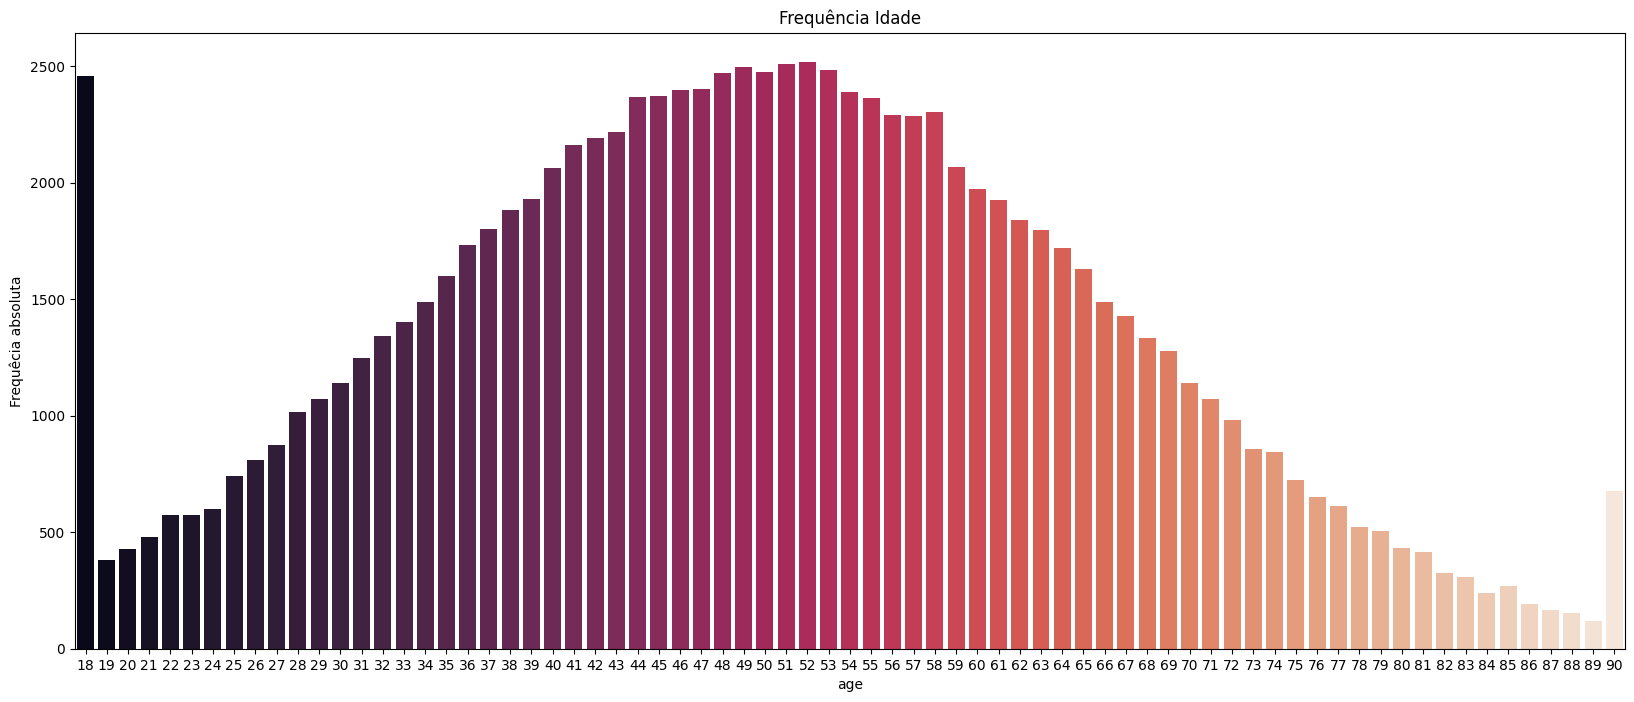

In [ ]:
plt.figure(figsize=(20,8))

sns.countplot(x = 'age', data = database, palette = 'rocket')
plt.title('Frequência Idade')
plt.ylabel('Frequêcia absoluta')
plt.show()

### **Insights obtidos com a análise gráfica:**

---
A maior parte dos participantes tem entre 40 e 60 anos, com pico perto dos 50. Jovens são minoria e a frequência diminui gradualmente após os 60. Isso reflete bem o perfil típico de estudos clínicos.

### Análise de Distribuição de Massa Corporal

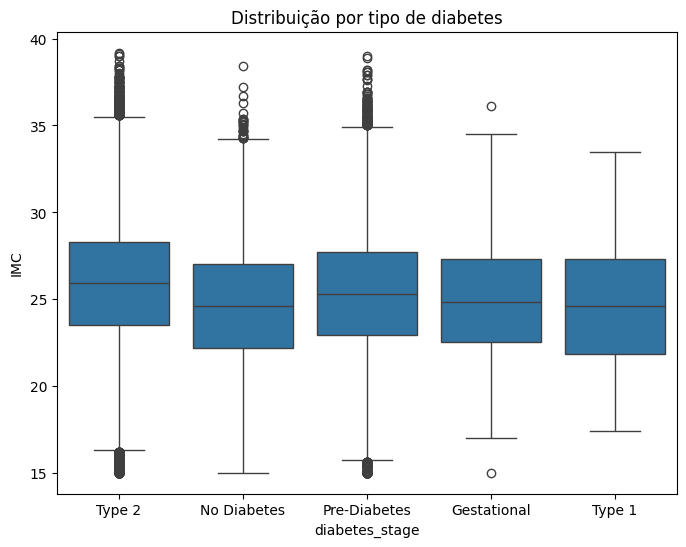

In [ ]:
plt.figure(figsize=(8,6))

sns.boxplot(x = 'diabetes_stage' , y = 'bmi', data = database)
plt.ylabel("IMC")
plt.title("Distribuição por tipo de diabetes")

plt.show()

### **Insights obtidos com a análise gráfica:**

---
- O BMI é parecido em todos os grupos, mas Type 2 tem mais valores altos e mais outliers de obesidade. Isso indica que o BMI sozinho não separa os tipos de diabetes, mas pode influenciar mais fortemente o risco de desenvolver o tipo 2

### Frequência relativa de pessoas com histórico familiar de Diabetes

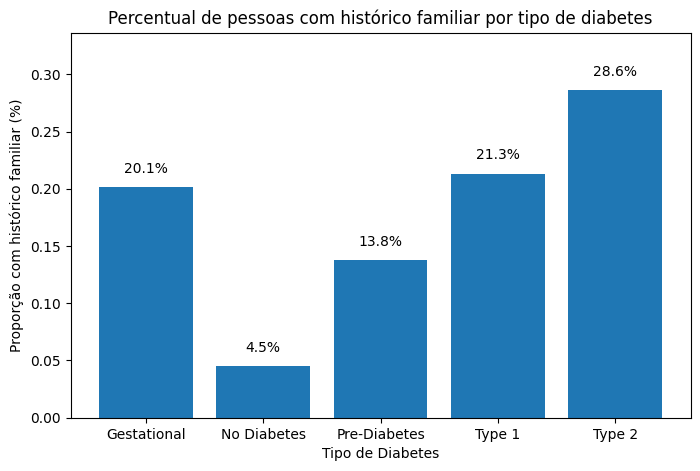

In [ ]:
plt.figure(figsize=(8,5))
database_prop = database.groupby("diabetes_stage")["family_history_diabetes"].mean()
bars = plt.bar(database_prop.index, database_prop.values)

plt.xlabel("Tipo de Diabetes")
plt.ylabel("Proporção com histórico familiar (%)")
plt.title("Percentual de pessoas com histórico familiar por tipo de diabetes")
plt.ylim(0, database_prop.values.max() + 0.05)

# Adicionar rótulos em porcentagem
for bar in bars:
    altura = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        altura + 0.01,
        f"{altura*100:.1f}%",
        ha='center', va='bottom',
        fontsize=10)
plt.show()

### **Insights obtidos com a análise gráfica:**

---

**Tipo 2 (28,6%)**
- O tipo de diabetes com maior influência genética visível é o Diabetes Tipo 2.
Quase 1 em cada 3 indivíduos com Diabetes Tipo 2 possui histórico familiar positivo. Isso reforça o papel da hereditariedade no desenvolvimento do Diabetes Tipo 2, que combina predisposição genética com fatores ambientais (alimentação, sedentarismo, idade, etc.).

**Tipo 1 (21,3%):**
- O Diabetes Tipo 1 aparece com 21,3%, também indicando influência genética significativa. Apesar de ser uma doença autoimune, existe componente hereditário — e o gráfico confirma isso.

**Gestational (20,1%):**
- O diabetes gestacional apresenta um percentual elevado de histórico familiar. Mulheres com predisposição genética têm maior risco de desenvolver diabetes durante a gravidez.

**Pré-Diabetes (13,8%):**
- Um percentual intermediário. Pessoas pré-diabéticas já mostram uma leve influência familiar, podendo evoluir para diabetes se outros fatores se combinarem (IMC, sedentarismo, alimentos ultraprocessados, idade).

**Sem Diabetes — Menor percentual (4,5%)**
- Apenas 4,5% das pessoas sem diabetes têm histórico familiar. Quem não tem histórico familiar apresenta significativamente menor predisposição genética.

<Axes: xlabel='age', ylabel='diabetes_risk_score'>

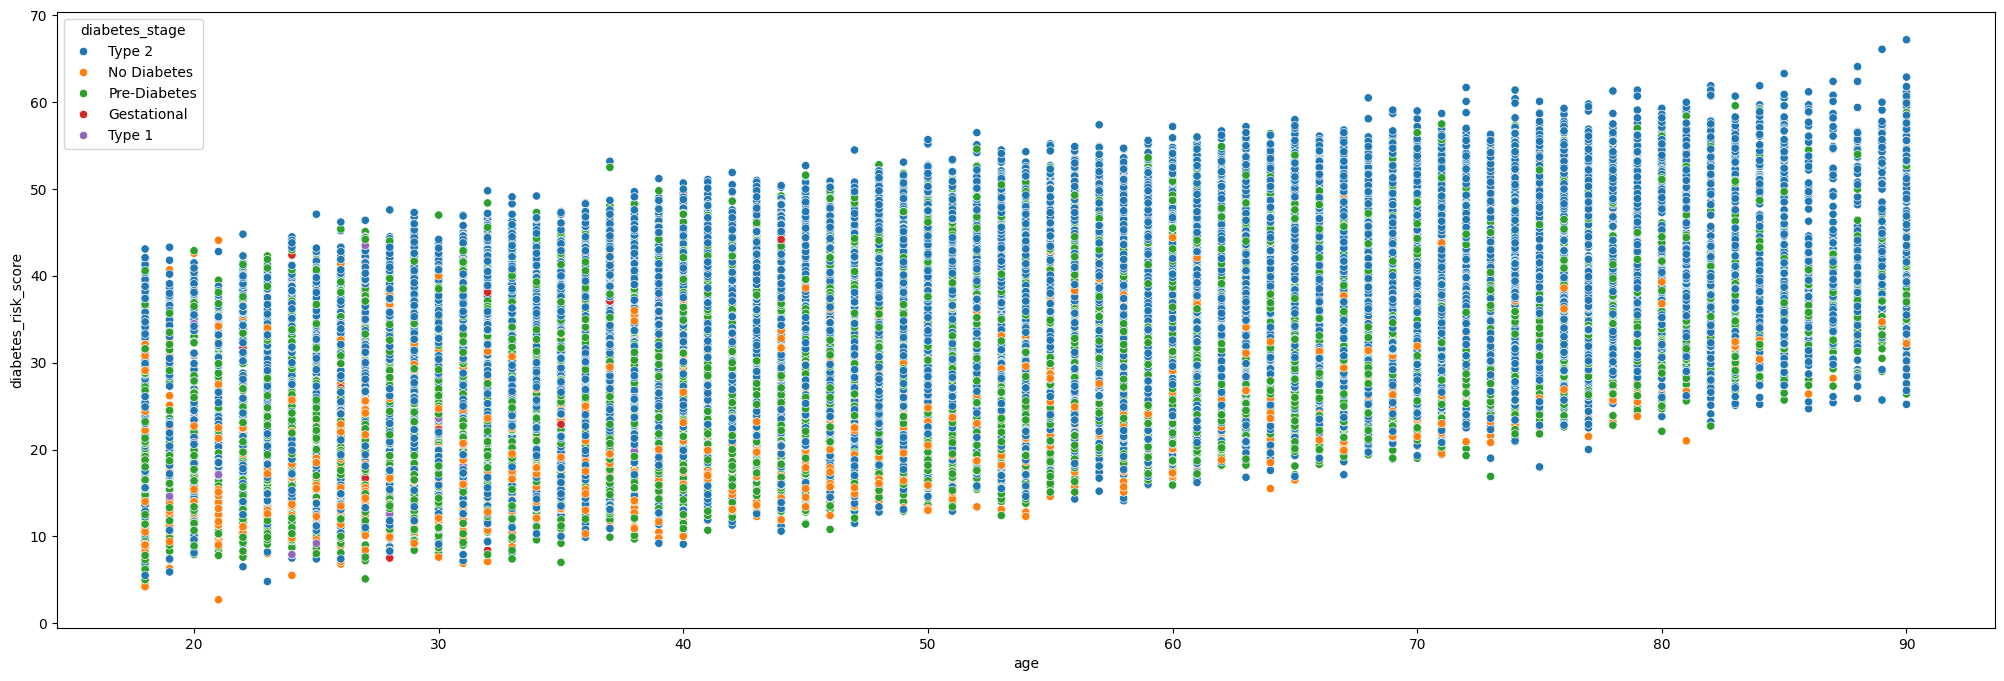

In [ ]:
plt.figure(figsize=(25,8))
sns.scatterplot(data = database, x = 'age', y = 'diabetes_risk_score', hue="diabetes_stage")


### **Insights obtidos com a análise gráfica:**

---

Esse tipo de visualização permite observar não apenas a correlação geral, mas também o comportamento de cada estágio da doença ao longo da idade.

**Análise:**
- Com o aumento da idade, o risco de diabetes cresce quase linearmente. O tipo 2 predomina valores altos, principalmente em adultos e idosos. Já os sem diabetes aparece nos menores riscos.
- Ao tentar realizar uma clusterização, o gráfico mostra uma distribuição linear entre os tipos de diabetes, sugerindo que não há diferença relevante na distribuição conforme tipo e idade para o risco de diabetes

## **Análise de Correlações**


---



### Visualização da correlação geral dos dados pelo mapa de calor

<Axes: >

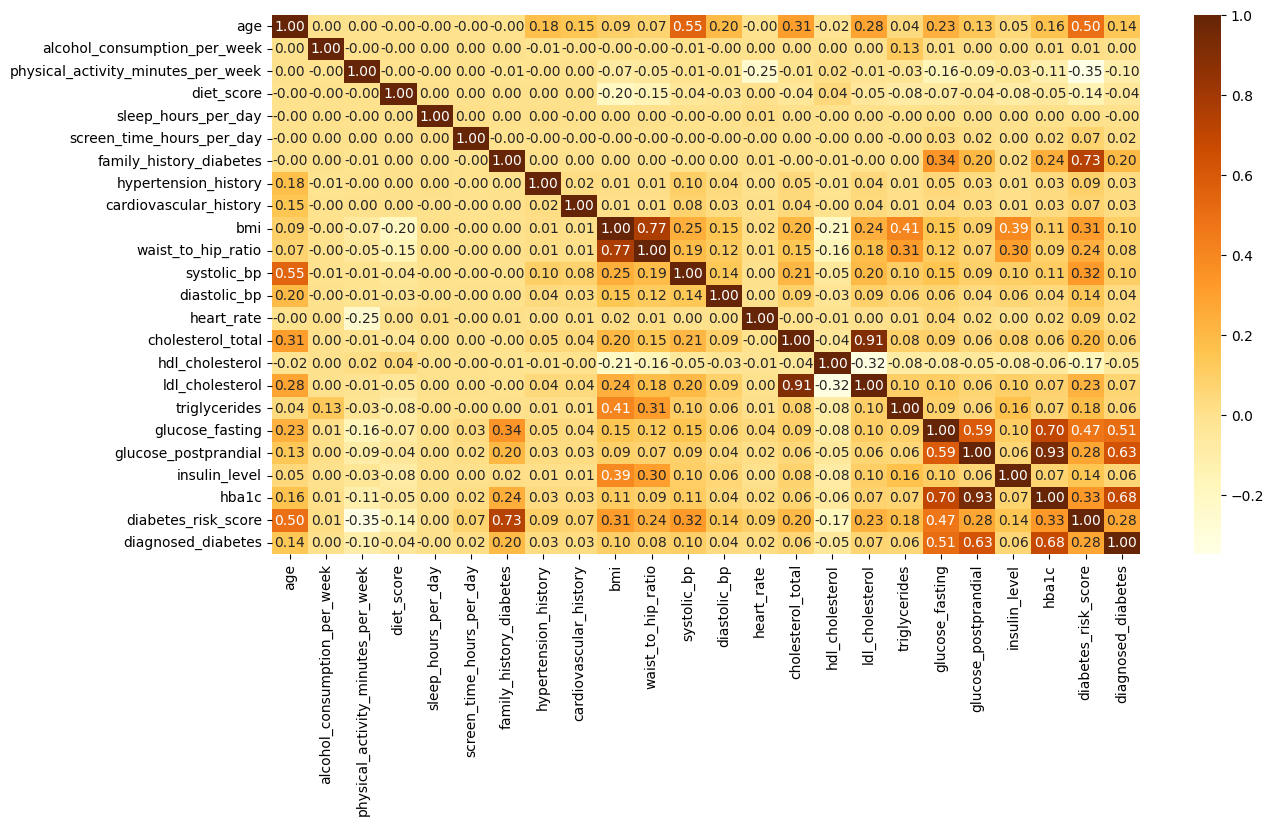

In [ ]:
dados5 = database.select_dtypes(include='number')
plt.figure(figsize=(14,7))
sns.heatmap(dados5.corr(),cmap="YlOrBr", annot = True, fmt=".2f")

### **Insights obtidos com a análise gráfica:**

---
Alta correlação
- Colesterol Total x LDL (r = 0,91)
- Risco de Diabetes x Histórico familiar (r = 0,73)
- Risco de Diabetes x Idade (0.5)
- Glicose após refeição x Hemoglobina Glicada (r = 0,93)

Diferenças observadas
- Dieta (r = -0,20) e atividade física (r = -0,07) possuem baixa correlação com IMC
- Histórico familiar está moderadamente ligado ao risco, mas pouco ao diagnóstico

### Análise de Correlação por Dispersão

A correlação é de:  0.50


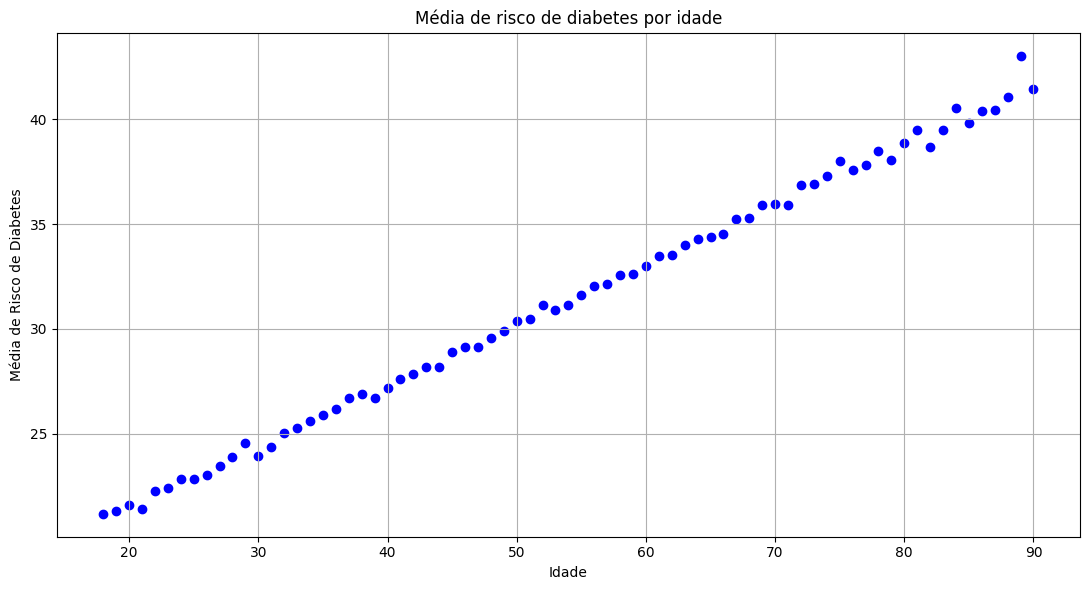

In [ ]:
#Plotagem gráfica dos dados de interesse
dados2 = media_por_idade = database.groupby("age")["diabetes_risk_score"].mean().reset_index()
plt.figure(figsize=(11, 6))
plt.scatter(media_por_idade["age"], media_por_idade["diabetes_risk_score"], color='blue')
plt.title("Média de risco de diabetes por idade")
plt.ylabel("Média de Risco de Diabetes")
plt.xlabel("Idade")
plt.grid(True)
plt.tight_layout()

print("A correlação é de:", f'{database['age'].corr(database['diabetes_risk_score']): .2f}')

### **Insights obtidos com a análise gráfica:**

---


- O gráfico mostra uma forte correlação positiva: quanto maior a idade, maior o risco de diabetes. A relação é praticamente linear, mostrando que o avanço da idade aumenta diretamente a probabilidade de desenvolver a doença